# Nepal Flood & Weather: Linear Regression
Linear Regression: river discharge from weather, Nepal Flood & Weather Dataset 2023-2026

Findings about the raw CSV that this script handles:
  * Dates are day-first (dd-mm-yyyy).
  * All 2023 rows (3,650) have weather columns shifted by one position relative
    to the header, e.g. 'temperature_mean_c' holds soil moisture. Fixed below.
  * latitude / longitude / elevation / DHM Station / river / basin are constants
    per station, so one-hot 'location' replaces them.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
TEST_START = "2025-09-01"   # test = final 12 months (includes a full monsoon)

In [25]:
# ---------------------------------------------------------------- load 
df = pd.read_csv("/Users/arijeetbhadra/Downloads/archive/nepal_flood_weather_dataset_kaggle_2023_2026.csv")
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

SOIL, RAIN, TEMP, DEW, PH = ("soil_moisture_0_100cm_m3m3", "rain_mm",
                             "temperature_mean_c", "dew_point_mean_c",
                             "precipitation_hours")
m = df["date"].dt.year == 2023            # shifted block
fixed = df.loc[m, [SOIL, RAIN, TEMP, DEW, PH]].copy()
df.loc[m, RAIN] = fixed[SOIL].values      # true rain       was in 'soil' column
df.loc[m, PH] = fixed[RAIN].values        # true precip hrs was in 'rain' column
df.loc[m, SOIL] = fixed[TEMP].values      # true soil       was in 'temp' column
df.loc[m, TEMP] = fixed[DEW].values       # true temp       was in 'dew' column
df.loc[m, DEW] = fixed[PH].values         # true dew point  was in 'precip_hours'
assert (df[DEW] <= df[TEMP] + 0.05).all() and df[SOIL].max() < 1

In [27]:
# ----------------------------------------------------------------- features
df = df.sort_values(["location", "date"]).reset_index(drop=True)
g = df.groupby("location")
for w in (3, 7, 14, 30):                  # antecedent rainfall (past-only)
    df[f"precip_{w}d"] = g["precipitation_mm"].transform(
        lambda s: s.rolling(w, min_periods=1).sum())
df["precip_lag1"] = g["precipitation_mm"].shift(1)
df["soil_lag1"] = g[SOIL].shift(1)
df["doy_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofyear / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofyear / 365.25)
df["log_q"] = np.log1p(df["river_discharge_m3s"])
df["log_q_lag1"] = g["log_q"].shift(1)    # yesterday's discharge (Model B only)
df = df.dropna().reset_index(drop=True)

weather = ["precipitation_mm", RAIN, PH, SOIL, TEMP, DEW,
           "relative_humidity_mean_pct", "wind_speed_max_kmh",
           "wind_gusts_max_kmh", "precip_lag1", "precip_3d", "precip_7d",
           "precip_14d", "precip_30d", "soil_lag1", "doy_sin", "doy_cos"]
FEATURES = {
    "A: weather + station": weather,
    "B: A + yesterday's discharge": weather + ["log_q_lag1"],
}

train, test = df[df["date"] < TEST_START], df[df["date"] >= TEST_START]
print(f"train {len(train)} rows | test {len(test)} rows\n")

train 9730 rows | test 3650 rows



In [29]:
# -------------------------------------------------------------- fit + score
results, preds = {}, {}
for name, num in FEATURES.items():
    pre = ColumnTransformer([("num", StandardScaler(), num),
                             ("loc", OneHotEncoder(handle_unknown="ignore"), ["location"])])
    model = Pipeline([("pre", pre), ("lr", LinearRegression())])
    model.fit(train[num + ["location"]], train["log_q"])
    p_log = model.predict(test[num + ["location"]])
    p = np.clip(np.expm1(p_log), 0, None)
    y = test["river_discharge_m3s"]
    results[name] = dict(
        R2_log=r2_score(test["log_q"], p_log),
        R2=r2_score(y, p),
        MAE=mean_absolute_error(y, p),
        RMSE=float(np.sqrt(mean_squared_error(y, p))))
    preds[name] = (p, model)

base_p = np.expm1(np.full(len(test), train["log_q"].mean()))
print(pd.DataFrame(results).T.round(3).to_string())
print(f"\nBaseline (train mean, log): R2 on original scale = "
      f"{r2_score(test['river_discharge_m3s'], base_p):.3f}")

# per-station R2 for Model A (log scale)
best = "A: weather + station"
pA, mA = preds[best]
tmp = test.assign(pred_log=np.log1p(pA))
print("\nPer-station R2 (log scale), Model A:")
print(tmp.groupby("location").apply(
    lambda d: r2_score(d["log_q"], d["pred_log"]), include_groups=False).round(3))

# coefficients (Model A, standardized numeric features)
names = mA.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(mA.named_steps["lr"].coef_, index=names)
print("\nModel A coefficients (log-discharge per 1 SD):")
print(coefs[coefs.index.str.startswith("num__")].sort_values(key=abs, ascending=False).round(3))

                              R2_log     R2     MAE    RMSE
A: weather + station           0.890  0.336  12.208  53.171
B: A + yesterday's discharge   0.992  0.956   2.167  13.645

Baseline (train mean, log): R2 on original scale = -0.064

Per-station R2 (log scale), Model A:
location
Bahrabise              0.927
Belsot                 0.600
Bhada Bridge          -0.407
Chameliya/Nayalbadi    0.860
Chatara                0.756
Chisapani              0.194
Devghat                0.774
Khokana                0.537
Kusum                  0.542
Rasuwagadhi            0.836
dtype: float64

Model A coefficients (log-discharge per 1 SD):
num__soil_lag1                     0.581
num__soil_moisture_0_100cm_m3m3   -0.456
num__precipitation_mm             -0.390
num__dew_point_mean_c             -0.342
num__rain_mm                       0.310
num__temperature_mean_c            0.304
num__relative_humidity_mean_pct    0.301
num__doy_sin                      -0.256
num__precip_30d                  

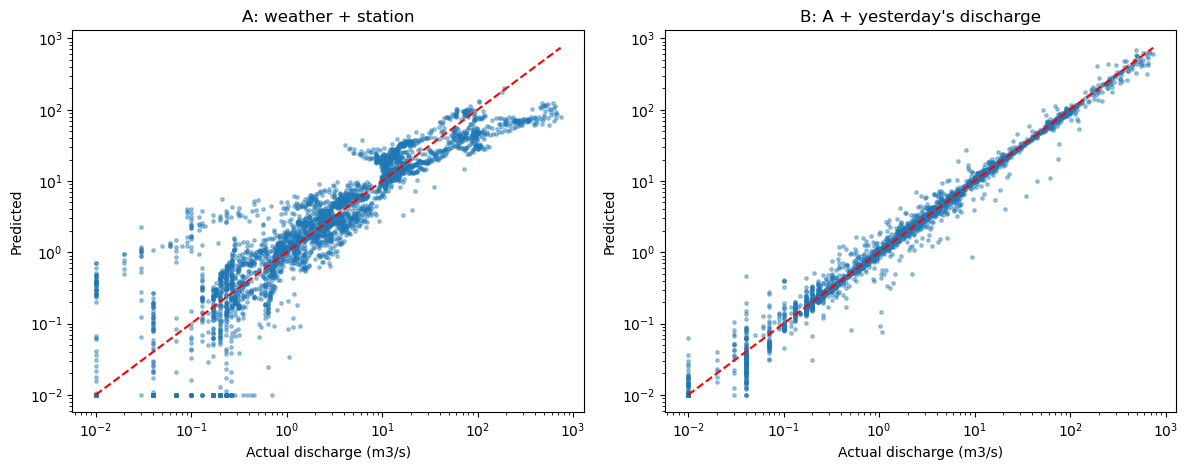

In [43]:
# -------------------------------------------------------------------- plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for a, name in zip(ax, FEATURES):
    p = preds[name][0]
    a.scatter(test["river_discharge_m3s"] + 0.01, p + 0.01, s=6, alpha=.4)
    lim = [0.01, max(test["river_discharge_m3s"].max(), p.max())]
    a.plot(lim, lim, "r--")
    a.set(xscale="log", yscale="log", xlabel="Actual discharge (m3/s)",
          ylabel="Predicted", title=name)
plt.tight_layout()
plt.savefig("linear_regression_results.png", dpi=150)
plt.show()